In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pytorch_lightning as pl
from torch.distributions import Bernoulli
import xarray as xr
import xrft
import numpy as np
import datetime
import matplotlib.pyplot as plt
import src.data
import src.utils
import os
from scipy.stats import multivariate_normal
import tqdm
import pandas as pd
from xrpatcher import XRDAPatcher
from functools import partial
import pandas as pd

In [2]:
device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")

# Utils functions

In [3]:
def rmse_based_scores_from_ds(ds, ref_variable='tgt', study_variable='out'):
    #mask = ~np.isnan(ds['input'])
    try:
        return rmse_based_scores(ds[ref_variable], ds[study_variable])[2:]
    except:
        return [np.nan, np.nan]

def psd_based_scores_from_ds(ds, ref_variable='tgt', study_variable='out'):
    print(ds)
    try:
        return psd_based_scores(ds[ref_variable], ds[study_variable])[1:]
    except:
        return [np.nan, np.nan]

def rmse_based_scores(da_rec, da_ref):
    rmse_t = (
        1.0
        - (((da_rec - da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
        / (((da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
    )
    rmse_xy = (((da_rec - da_ref) ** 2).mean(dim=("time"))) ** 0.5
    rmse_t = rmse_t.rename("rmse_t")
    rmse_xy = rmse_xy.rename("rmse_xy")
    reconstruction_error_stability_metric = rmse_t.std().values
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return (
        rmse_t,
        rmse_xy,
        np.round(leaderboard_rmse.values, 5).item(),
        np.round(reconstruction_error_stability_metric, 5).item(),
    )


def psd_based_scores(da_rec, da_ref):
    print('hello')
    err = da_rec - da_ref
    err["time"] = (err.time - err.time[0]) / np.timedelta64(1, "D")
    signal = da_ref
    signal["time"] = (signal.time - signal.time[0]) / np.timedelta64(1, "D")
    psd_err = xrft.power_spectrum(
        err, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()
    psd_signal = xrft.power_spectrum(
        signal, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()

    mean_psd_signal = psd_signal.mean(dim="lat").where(
        (psd_signal.freq_lon > 0.0) & (psd_signal.freq_time > 0), drop=True
    )
    
    mean_psd_err = psd_err.mean(dim="lat").where(
        (psd_err.freq_lon > 0.0) & (psd_err.freq_time > 0), drop=True
    )
    print(mean_psd_err)
    psd_based_score = 1.0 - mean_psd_err / mean_psd_signal
    level = [0.5]
    cs = plt.contour(
        1.0 / psd_based_score.freq_lon.values,
        1.0 / psd_based_score.freq_time.values,
        psd_based_score,
        level,
    )
    x05, y05 = cs.collections[0].get_paths()[0].vertices.T
    plt.close()

    shortest_spatial_wavelength_resolved = np.min(x05)
    shortest_temporal_wavelength_resolved = np.min(y05)
    psd_da = 1.0 - mean_psd_err / mean_psd_signal
    psd_da.name = "psd_score"
    return (
        psd_da.to_dataset(),
        np.round(shortest_spatial_wavelength_resolved, 3).item(),
        np.round(shortest_temporal_wavelength_resolved, 3).item(),
    )

In [4]:
def delete_files(file_paths):
    for file_path in file_paths:
        if os.path.exists(file_path):
            os.remove(file_path)
        else:
            print(f"File not found: {file_path}")

def plot_tensor(tensor, title = 'Position Plot'):
    pos_tensor_numpy = tensor.numpy()
    plt.imshow(pos_tensor_numpy, cmap='viridis', interpolation='nearest')
    plt.colorbar()
    plt.title(title)
    plt.show()

# Gambel-softmax function

In [5]:
def gumbel_softmax(pos_tensor):
    pos_tensor_flattened = torch.log(pos_tensor.view(-1).float())
    #uniform = torch.rand(pos_tensor_flattened.size(), dtype=pos_tensor_flattened.dtype, layout=pos_tensor_flattened.layout, device=pos_tensor_flattened.device)
    uniform = torch.rand_like(pos_tensor_flattened)
    gumbel = -torch.log(-torch.log(uniform))
    temp = nn.Parameter(torch.tensor(1), requires_grad=False)
    noisy_logits = (pos_tensor_flattened + gumbel) / temp

    samples_flatten = F.softmax(noisy_logits, dim=-1)
    samples_output = samples_flatten.view(pos_tensor.shape[0], pos_tensor.shape[1],  pos_tensor.shape[2])

    return samples_flatten, samples_output

In [6]:
def samples_mask(samples_flatten, shape, sampling_rate):
    # Create a tensor of zeros with the same shape as samples_flatten
    mask_total = torch.zeros_like(samples_flatten)
    sampled_indices_temp = torch.multinomial(samples_flatten, num_samples=int(samples_flatten.shape[0]*sampling_rate))
    mask = torch.zeros_like(samples_flatten)
    # Set the positions specified by sampled_indices to 1
    mask[sampled_indices_temp] = 1
    mask_total +=mask
    mask_output = mask_total.view(shape[0], shape[1],shape[2])
    return mask_output

# Loading of the OI method

In [7]:
def oi(outgrid_da,
        patcher_cls,
        obs,
        obs_var='ecs',
        lt=pd.to_timedelta('7D'), lx=1., ly=1.,
        noise=0.05,
        obs_dt=pd.to_timedelta('1D'),
        obs_dx=0.25,
        obs_dy=0.25,
        device='cuda'
    ):

    """
    outgrid_da: xr.DataArray with (time, lat, lon) dims and coords with target region, period and resolution, will be updated inplace
    patcher_cls: callable that return an DataArray iterator of slices of outgrid_da to be sequentially solved for
    obs: xr.Dataset of observations with (time, lat, lon) coords
    obs_var: observation values to be interpolated
    lt: time decorellation factor for covariance model
    lx: longitudinal decorellation factor for covariance model
    ly: latitudinal decorellation factor for covariance model
    noise: noise variance
    obs_dt: temporal bin size for obs coarsening 
    obs_dx: longitudinal bin size for obs coarsening 
    obs_dy: latitudinal bin size for obs coarsening 
    device: torch device to run oi on 'cpu' or 'cuda' gpu
    
    Returns: xr.DataArray outgrid_da filled with interpolation
    """

    patcher = patcher_cls(outgrid_da)
    # 1 Iterate over each patch
    for p in tqdm.tqdm(patcher):
        # 2 select observations within 2 stds in each direction
        pobs = obs.where(
            (np.isfinite(obs[obs_var]))
        &  (obs.time >= (p.time.min() - 2 * lt))
        &  (obs.time <= (p.time.max() + 2 * lt))
        &  (obs.lat >= (p.lat.min() - 2 * ly))
        &  (obs.lat <= (p.lat.max() + 2 * ly))
        &  (obs.lon >= (p.lon.min() - 2 * lx))
        &  (obs.lon <= (p.lon.max() + 2 * lx)), drop=True
        )

        # 3 Coarsen the observations to a certain resolution
        df = pobs.to_dataframe().reset_index().dropna()
        time_bins = pd.date_range(df['time'].min(), df['time'].max() + obs_dt, freq=obs_dt)
        lat_bins = np.arange(df['lat'].min(), df['lat'].max() + obs_dx, obs_dx)
        lon_bins = np.arange(df['lon'].min(), df['lon'].max() + obs_dy, obs_dy)

        ## bin
        df['time_bin'] = pd.cut(df['time'], time_bins)
        df['lat_bin'] = pd.cut(df['lat'], lat_bins)
        df['lon_bin'] = pd.cut(df['lon'], lon_bins)

        ## Average data within each bin
        df_averaged = df.groupby(['time_bin', 'lat_bin', 'lon_bin'], observed=True).mean(numeric_only=False).reset_index()
        pobs_coarse = df_averaged.dropna().set_index('time')[[obs_var, 'lat', 'lon']].to_xarray()

        # Create flat coordinates and values array
        obs_values, obs_time, obs_lat, obs_lon = pobs_coarse[obs_var].values, pobs_coarse.time.values, pobs_coarse.lat.values, pobs_coarse.lon.values
        gtime, glat, glon = (np.ravel(x) for x in np.meshgrid(p.time, p.lat, p.lon, indexing='ij'))

        # Convert to torch tensor
        d0 = pd.to_datetime("2010-01-01").to_datetime64()
        _obs_time = (obs_time - d0) / lt
        _gtime = (gtime -d0) / lt
        _lt = lt / lt
        (
            tobs_values, tobs_time, tobs_lat, tobs_lon,
            tgtime, tglat, tglon
        ) = (
            torch.from_numpy(t).to(device).float()
            for t in [
                obs_values, _obs_time, obs_lat, obs_lon,
                _gtime, glat, glon
            ]
        )
        # 4 Solve oi
        BHt = torch.exp(
                - ((tgtime[:, None] - tobs_time[None, :]) / _lt)**2
                - ((tglon[:, None] - tobs_lon[None, :]) / lx)**2
                - ((tglat[:, None] - tobs_lat[None, :]) / ly)**2
            )
        HBHt = torch.exp(-((tobs_time[:, None] - tobs_time[None, :]) / _lt)**2 -
                        ((tobs_lon[:, None] - tobs_lon[None, :]) / lx)**2 -
                        ((tobs_lat[:, None] - tobs_lat[None, :]) / ly)**2)

        nobs = len(tobs_time)
        R = torch.diag(torch.full((nobs,), noise**2, device=tobs_time.device))


        Coo = HBHt + R
        Mi = torch.linalg.inv(Coo)
        Iw = torch.mm(BHt, Mi)
        sol=torch.mv(Iw, tobs_values)

        # fill in outputput da
        p[:] = sol.detach().cpu().numpy().reshape(p.shape)

    return outgrid_da

In [8]:
def oi_pytorch(outgrid_da,
               patcher_cls,
               obs,
               obs_var='ecs',
               lt=7*24*3600,  # Time de-correlation factor in seconds
               lx=1., ly=1.,
               noise=0.05,
               obs_dt=24*3600,  # Temporal bin size in seconds
               obs_dx=0.25, obs_dy=0.25,
               device='cuda'):
    patcher = patcher_cls(outgrid_da)
    obs = torch.tensor(obs.ecs.values, dtype=torch.float32, device=device)
    outgrid_da = torch.tensor(outgrid_da.ecs.values, dtype=torch.float32, device=device)
    device = torch.device(device)
    outgrid_da = outgrid_da.to(device)
    obs = obs.to(device)

    for p in tqdm.tqdm(patcher):
        # Select observations within 2 stds in each direction
        mask = (torch.isfinite(obs)) & \
               (obs.time >= (p.time.min() - 2 * lt)) & \
               (obs.time <= (p.time.max() + 2 * lt)) & \
               (obs.lat >= (p.lat.min() - 2 * ly)) & \
               (obs.lat <= (p.lat.max() + 2 * ly)) & \
               (obs.lon >= (p.lon.min() - 2 * lx)) & \
               (obs.lon <= (p.lon.max() + 2 * lx))
        pobs = obs[mask]
        # Coarsen the observations to a certain resolution
        time_bins = torch.linspace(pobs.time.min(), pobs.time.max() + obs_dt, int(obs_dt / pobs.time.dt.seconds)).to(device)
        lat_bins = torch.linspace(pobs.lat.min(), pobs.lat.max() + obs_dx, int(obs_dx / pobs.lat.dt.seconds)).to(device)
        lon_bins = torch.linspace(pobs.lon.min(), pobs.lon.max() + obs_dy, int(obs_dy / pobs.lon.dt.seconds)).to(device)
        
        # Bin and average data within each bin
        _, indices = torch.searchsorted(time_bins, pobs.time), torch.stack([torch.searchsorted(lat_bins, pobs.lat), torch.searchsorted(lon_bins, pobs.lon)], dim=-1)
        pobs_coarse = torch.cat([
            pobs[pobs.time.argsort()].groupby(indices.T).mean(dim=0)[obs_var],
            pobs[pobs.time.argsort()].groupby(indices.T).mean(dim=0)['lat'],
            pobs[pobs.time.argsort()].groupby(indices.T).mean(dim=0)['lon']
        ], dim=-1)
        
        # Prepare tensors for computation
        obs_values, obs_time, obs_lat, obs_lon = pobs_coarse[obs_var], pobs_coarse.time, pobs_coarse.lat, pobs_coarse.lon
        gtime, glat, glon = torch.meshgrid([p.time, p.lat, p.lon], indexing='ij')
        
        # Compute distances and prepare tensors
        _obs_time = (obs_time - torch.tensor("2010-01-01", dtype=torch.float64, device=device)).abs() / lt
        _gtime = (gtime - torch.tensor("2010-01-01", dtype=torch.float64, device=device)).abs() / lt
        _lt = lt / lt
        # Covariance matrix components
        BHt = torch.exp(-(((gtime[:, :, :] - obs_time.unsqueeze(0)) / _lt)**2 - ((glat[:, :, :] - obs_lat.unsqueeze(0)) / ly)**2 - ((glon[:, :, :] - obs_lon.unsqueeze(0)) / lx)**2))
        HBHt = torch.exp(-(((obs_time - obs_time.unsqueeze(0)) / _lt)**2 - ((obs_lon - obs_lon.unsqueeze(0)) / lx)**2 - ((obs_lat - obs_lat.unsqueeze(0)) / ly)**2))
        
        # Noise term
        R = torch.diag(torch.full((len(obs_time),), noise**2, device=device))
        
        # Solve OI
        Coo = HBHt + R
        Mi = torch.inverse(Coo)
        Iw = torch.matmul(BHt, Mi)
        sol = torch.matmul(Iw, obs_values.unsqueeze(0))
        
        # Fill in output DA
        p[:] = sol.squeeze().cpu().numpy().reshape(p.shape)

    return torch.from_numpy(outgrid_da.values).to(device)

In [ ]:
def select_and_coarsen_observations(obs_time, obs_lat, obs_lon, obs_values, 
                                    p_time_min, p_time_max, p_lat_min, p_lat_max, p_lon_min, p_lon_max, 
                                    obs_dt, obs_dx, obs_dy, std_time, std_lat, std_lon):
    """
    Select observations within 2 standard deviations and coarsen them to a specified resolution.
    
    Parameters:
    - obs_time, obs_lat, obs_lon: PyTorch tensors for the observations' time, latitude, and longitude.
    - obs_values: PyTorch tensor for the observations' values.
    - p_time_min, p_time_max, p_lat_min, p_lat_max, p_lon_min, p_lon_max: Bounds for the patch.
    - obs_dt, obs_dx, obs_dy: Desired resolution for time, latitude, and longitude.
    - std_time, std_lat, std_lon: Standard deviations for time, latitude, and longitude.
    
    Returns:
    - Coarsened observations as a PyTorch tensor.
    """
    
    # Select observations within 2 STDs
    time_min_bound = p_time_min - 2 * std_time
    time_max_bound = p_time_max + 2 * std_time
    lat_min_bound = p_lat_min - 2 * std_lat
    lat_max_bound = p_lat_max + 2 * std_lat
    lon_min_bound = p_lon_min - 2 * std_lon
    lon_max_bound = p_lon_max + 2 * std_lon

    selected_indices = (obs_time >= time_min_bound) & (obs_time <= time_max_bound) & \
                       (obs_lat >= lat_min_bound) & (obs_lat <= lat_max_bound) & \
                       (obs_lon >= lon_min_bound) & (obs_lon <= lon_max_bound)

    selected_obs_time = obs_time[selected_indices]
    selected_obs_lat = obs_lat[selected_indices]
    selected_obs_lon = obs_lon[selected_indices]
    selected_obs_values = obs_values[selected_indices]
    
    # Coarsen observations
    # Define bin edges for time, latitude, and longitude
    time_bins = torch.arange(start=time_min_bound, end=time_max_bound + obs_dt, step=obs_dt)
    lat_bins = torch.arange(start=lat_min_bound, end=lat_max_bound + obs_dx, step=obs_dx)
    lon_bins = torch.arange(start=lon_min_bound, end=lon_max_bound + obs_dy, step=obs_dy)

    # Digitize observations
    time_bin_indices = torch.bucketize(selected_obs_time, time_bins) - 1
    lat_bin_indices = torch.bucketize(selected_obs_lat, lat_bins) - 1
    lon_bin_indices = torch.bucketize(selected_obs_lon, lon_bins) - 1

    # Initialize tensor for coarsened observations
    coarsened_obs = torch.zeros((len(time_bins)-1, len(lat_bins)-1, len(lon_bins)-1))
    
    # Iterate over bins and calculate mean values
    for t in range(len(time_bins)-1):
        for lat in range(len(lat_bins)-1):
            for lon in range(len(lon_bins)-1):
                mask = (time_bin_indices == t) & (lat_bin_indices == lat) & (lon_bin_indices == lon)
                if mask.any():
                    coarsened_obs[t, lat, lon] = selected_obs_values[mask].mean()
    
    return coarsened_obs

In [ ]:
def oi_torch(outgrid_da, patcher_cls, obs, obs_var='ecs', lt=7, lx=1., ly=1., noise=0.05, obs_dt=1, obs_dx=0.25, obs_dy=0.25, device='cuda'):
    # Convert inputs to PyTorch tensors
    lt = torch.tensor(lt, dtype=torch.float32, device=device)
    lx = torch.tensor(lx, dtype=torch.float32, device=device)
    ly = torch.tensor(ly, dtype=torch.float32, device=device)
    noise = torch.tensor(noise, dtype=torch.float32, device=device)
    
    # Assuming outgrid_da and obs are already PyTorch tensors
    outgrid_da = outgrid_da.to(device)
    obs = obs.to(device)
    
    patcher = patcher_cls(outgrid_da)
    for p in tqdm.tqdm(patcher):
        # Extract patch bounds (assuming patcher provides this information)
        p_time_min, p_time_max, p_lat_min, p_lat_max, p_lon_min, p_lon_max = p.bounds()
        
        # Select and coarsen observations within the patch
        # Assuming obs_time, obs_lat, obs_lon, and obs_values are extracted from 'obs'
        coarsened_obs = select_and_coarsen_observations(obs_time, obs_lat, obs_lon, obs_values, 
                                                         p_time_min, p_time_max, p_lat_min, p_lat_max, p_lon_min, p_lon_max, 
                                                         obs_dt, obs_dx, obs_dy, lt, lx, ly)
        
        # Assuming coarsened_obs contains time, lat, lon, and values in a structured format
        tobs_time, tobs_lat, tobs_lon, tobs_values = coarsened_obs
        
        # Solve OI using PyTorch operations (as previously defined)
        # Update outgrid_da directly with the solution tensor
        p[:] = sol.detach().reshape(p.shape)
    
    return outgrid_da

# Load ecs data and OI parameters

In [9]:
tgt_ecs = xr.open_dataset('/DATASET/NATL/NATL60GULF-CJM165_cutoff_freq_regrid_0_1000m.nc')

latitudes = tgt_ecs['lat']
longitudes = tgt_ecs['lon']

inp_da = tgt_ecs.sel(time=slice(tgt_ecs.time[40], tgt_ecs.time[40] + pd.Timedelta(days=44)))
inp_da.ecs
inp_da 

<xarray.Dataset>
Dimensions:              (time: 45, lat: 240, lon: 240)
Coordinates:
  * lat                  (lat) float64 32.0 32.05 32.1 ... 43.85 43.9 43.95
  * lon                  (lon) float64 -65.95 -65.9 -65.85 ... -54.05 -54.0
  * time                 (time) datetime64[ns] 2012-11-10T12:00:00 ... 2012-1...
Data variables:
    cutoff_freq          (time, lat, lon) float64 ...
    ecs                  (time, lat, lon) float64 ...
    ecs_sound_speed      (time, lat, lon) float64 ...
    surface_sound_speed  (time, lat, lon) float64 ...
    surface_temp         (time, lat, lon) float64 ...
    surface_sal          (time, lat, lon) float64 ...

In [10]:
sampling_rate = 0.001
#optimizer =  optim.SGD(lit_mod.parameters(), lr=0.01)

n_draw = 10
n_iter = 100

file_paths = [
    '/DATASET/envs/oscar/ConcreteAE/input_da.nc',
    '/DATASET/envs/oscar/ConcreteAE/mask_output_ds.nc'
]

In [11]:
matrix_size = [45,latitudes.shape[0],longitudes.shape[0]] 
pos_matrix = np.ones(matrix_size)
pos_matrix = pos_matrix/ np.sum(pos_matrix, axis=0, keepdims=True)

size = 240

# Define the mean vector (center of the Gaussian)
mean = np.array([120, 120])

# Define the covariance matrix (spread of the Gaussian)
# This example uses a diagonal matrix for simplicity, but you can adjust it as needed
cov = np.array([[240, 0], [0, 240]])

# Generate the 2D Gaussian distribution
x, y = np.mgrid[0:size, 0:size]
pos = np.dstack((x, y))
rv = multivariate_normal(mean, cov)
prob_distribution = rv.pdf(pos)
replicated_prob_distribution = np.tile(prob_distribution[np.newaxis, :, :], (45, 1, 1))


# Define the mean and covariance matrix for the Gaussian distribution
mean = [0, 0]
cov = np.identity(2)

# Generate a 2D Gaussian distribution
#pos_matrix_2d = np.random.multivariate_normal(mean, cov, (240, 240))
#pos_matrix = np.tile(pos_matrix_2d[np.newaxis, :], 45)

# Normalize the distribution so that the sum of all elements equals 1
# Sum over both axes (latitude and longitude) to get a scalar value
#pos_matrix = replicated_prob_distribution
# Now, pos_matrix represents a 2D Gaussian distribution centered at the origin

pos_tensor = torch.from_numpy(pos_matrix)
pos_tensor = pos_tensor.float()

In [12]:
print(prob_distribution)

[[5.80684155e-30 9.55393839e-30 1.56536398e-29 ... 2.55410459e-29
  1.56536398e-29 9.55393839e-30]
 [9.55393839e-30 1.57189994e-29 2.57547772e-29 ... 4.20224276e-29
  2.57547772e-29 1.57189994e-29]
 [1.56536398e-29 2.57547772e-29 4.21978864e-29 ... 6.88516002e-29
  4.21978864e-29 2.57547772e-29]
 ...
 [2.55410459e-29 4.20224276e-29 6.88516002e-29 ... 1.12340765e-28
  6.88516002e-29 4.20224276e-29]
 [1.56536398e-29 2.57547772e-29 4.21978864e-29 ... 6.88516002e-29
  4.21978864e-29 2.57547772e-29]
 [9.55393839e-30 1.57189994e-29 2.57547772e-29 ... 4.20224276e-29
  2.57547772e-29 1.57189994e-29]]


In [13]:
pos_matrix.shape

(45, 240, 240)

In [14]:
print(matrix_size)

[45, 240, 240]


In [15]:
delete_files(file_paths)
samples_position, _ = gumbel_softmax(pos_tensor)
samples_mask_positions = samples_mask(samples_position, [pos_tensor.shape[0], pos_tensor.shape[1], pos_tensor.shape[2]], sampling_rate)

# Mask creation for Dataloader
mask_output_np = samples_mask_positions.numpy()
mask_output_ds = xr.Dataset({'pos': (['time','lat', 'lon'], mask_output_np)}, coords={ 'time': inp_da.time, 'lat': tgt_ecs.lat, 'lon': tgt_ecs.lon})
#mask_output_ds = mask_output_ds.expand_dims({'time': tgt_ecs.time.size})
mask_output_ds.transpose('time', 'lat', 'lon')

mask = (mask_output_ds == 1)
masked_input_da = inp_da.ecs.where(mask)
masked_input_da = masked_input_da.rename({'pos': 'ecs'})
masked_input_da.to_netcdf('/DATASET/envs/oscar/ConcreteAE/input_da.nc')
mask_output_ds.to_netcdf('/DATASET/envs/oscar/ConcreteAE/mask_output_ds.nc')
inp_da.to_netcdf('/DATASET/envs/oscar/ConcreteAE/tgt_da.nc')

In [16]:
masked_input_da

<xarray.Dataset>
Dimensions:  (time: 45, lat: 240, lon: 240)
Coordinates:
  * lat      (lat) float64 32.0 32.05 32.1 32.15 32.2 ... 43.8 43.85 43.9 43.95
  * lon      (lon) float64 -65.95 -65.9 -65.85 -65.8 ... -54.1 -54.05 -54.0
  * time     (time) datetime64[ns] 2012-11-10T12:00:00 ... 2012-12-24T12:00:00
Data variables:
    ecs      (time, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan

In [17]:
patcher_cls= partial(XRDAPatcher,
            patches=dict(time=5, lat=40, lon=40),
            strides=dict(time=5, lat=40, lon=40)
        )
    # 1 Iterate over each patch
# Define the parameters for the interpolation
lt = pd.to_timedelta('7D')
lx = 1.5
ly = 1.5
noise = 0.05
obs_dt = pd.to_timedelta('1D')
obs_dx = 0.25
obs_dy = 0.25

outgrid_da = xr.DataArray(np.zeros_like(inp_da.ecs.values), dims=inp_da.dims, coords=inp_da.coords)

# Call the oi function
interpolated_da = oi(
    outgrid_da = xr.DataArray(np.zeros_like(inp_da.ecs.values), dims=inp_da.dims, coords=inp_da.coords)
    , 
    patcher_cls = partial(XRDAPatcher,
            patches=dict(time=5, lat=40, lon=40),
            strides=dict(time=5, lat=40, lon=40)
        ),
        obs = masked_input_da.transpose('time', 'lat', 'lon'), 
        obs_var='ecs', 
        lt=lt, 
        lx=lx, 
        ly=ly, 
        noise=noise, 
        obs_dt=obs_dt, 
        obs_dx=obs_dx, 
        obs_dy=obs_dy,
        device=device)

100%|██████████| 324/324 [00:29<00:00, 10.85it/s]


In [18]:
class MyModel_OI(nn.Module):
    def __init__(self, pos_distribution, device):
        super(MyModel_OI, self).__init__()
        self.pos_distribution = nn.Parameter(pos_distribution)
        #self.shape = [self.pos_distribution.shape[0], self.pos_distribution.shape[1]]
        self.shape = [45, 240, 240]
        self.lt = pd.to_timedelta('7D')
        self.lx = 1.5
        self.ly = 1.5
        self.noise = 0.05
        self.obs_dt = pd.to_timedelta('1D')
        self.obs_dx = 0.25
        self.obs_dy = 0.25

        self.patcher_cls= partial(XRDAPatcher,
            patches=dict(time=5, lat=40, lon=40),
            strides=dict(time=5, lat=40, lon=40)
            )
        self.device = device
    def forward(self):
        samples_position, _ = gumbel_softmax(self.pos_distribution)
        samples_mask_positions = samples_mask(samples_position, self.shape, sampling_rate)
        #samples_mask_positions = samples_mask(self.pos_distribution, self.shape, sampling_rate)
        mask_output_np = samples_mask_positions.cpu().numpy()
        mask_output_ds = xr.Dataset({'pos': (['time','lat', 'lon'], mask_output_np)}, coords={ 'time': inp_da.time, 'lat': tgt_ecs.lat, 'lon': tgt_ecs.lon})
        #mask_output_ds = mask_output_ds.expand_dims({'time': tgt_ecs.time.size})
        mask_output_ds.transpose('time', 'lat', 'lon')

        mask = (mask_output_ds == 1)
        masked_input_da = inp_da.ecs.where(mask)
        masked_input_da = masked_input_da.rename({'pos': 'ecs'})
        masked_input_da.to_netcdf('/DATASET/envs/oscar/ConcreteAE/input_da.nc')
        mask_output_ds.to_netcdf('/DATASET/envs/oscar/ConcreteAE/mask_output_ds.nc')

        output_da = oi(outgrid_da = xr.DataArray(np.zeros_like(inp_da.ecs.values), dims=inp_da.dims, coords=inp_da.coords), 
                       patcher_cls = self.patcher_cls,
                       obs = masked_input_da.transpose('time', 'lat', 'lon'), 
                       obs_var='ecs', 
                       lt=self.lt, 
                       lx=self.lx, 
                       ly=self.ly, 
                       noise=self.noise, 
                       obs_dt=self.obs_dt, 
                       obs_dx=self.obs_dx, 
                       obs_dy=self.obs_dy,
                       device=device)
        output_tensor = torch.from_numpy(output_da.values).float().to(device)
        inp_tensor = torch.from_numpy(inp_da.ecs.values).float().to(device)

        output_tensor.requires_grad_(True)
        inp_tensor.requires_grad_(True)
        loss_draw = (output_tensor - inp_tensor).pow(2).sqrt().mean()
        print(loss_draw)
        return output_da, loss_draw

In [19]:
# Initialize pos_distribution with pos_tensor
pos_distribution = nn.Parameter(pos_tensor.to(device), requires_grad=True)

# Initialize the model
model = MyModel_OI(pos_distribution, device)
model = model.to(device)

# Initialize the optimizer
optimizer = torch.optim.SGD([model.pos_distribution], lr=0.01)

# Number of training iterations
n_iter = 100

# Training loop
for k in range(n_iter):
    # Zero the gradients
    optimizer.zero_grad()

    # Forward pass: compute the output and loss
    _, loss = model.forward()

    # Backward pass: compute the gradient of the loss with respect to model parameters
    loss.backward()

    # Update the model parameters
    optimizer.step()

    # Print the loss for this iteration
    print(f"Iteration {k}, Loss {loss.item()}")

100%|██████████| 324/324 [00:15<00:00, 20.94it/s]


tensor(16.9625, device='cuda:7', grad_fn=<MeanBackward0>)
Iteration 0, Loss 16.962459564208984


100%|██████████| 324/324 [00:15<00:00, 21.16it/s]


tensor(17.1304, device='cuda:7', grad_fn=<MeanBackward0>)
Iteration 1, Loss 17.130367279052734


100%|██████████| 324/324 [00:14<00:00, 21.83it/s]


...

tensor(16.8225, device='cuda:7', grad_fn=<MeanBackward0>)
Iteration 25, Loss 16.822458267211914


100%|██████████| 324/324 [00:15<00:00, 21.05it/s]


tensor(17.7952, device='cuda:7', grad_fn=<MeanBackward0>)
Iteration 26, Loss 17.795207977294922


 30%|███       | 98/324 [00:04<00:10, 22.13it/s]


KeyboardInterrupt: 

In [ ]:
pos_tensor = pos_tensor.to(device)

pos_distribution = nn.Parameter(pos_tensor, requires_grad = True)
inp_da.to_netcdf('/DATASET/envs/oscar/ConcreteAE/tgt_da.nc')
pos_distribution = pos_distribution.to(device)
samples_position, _ = gumbel_softmax(pos_distribution)
samples_position = nn.Parameter(samples_position, requires_grad = True)
shape = [samples_position.shape[0]]
print(shape)

model = MyModel_OI(pos_distribution,device)
model = model.to(device)

optimizer = optim.SGD(model.parameters(), lr=0.01)

[2592000]


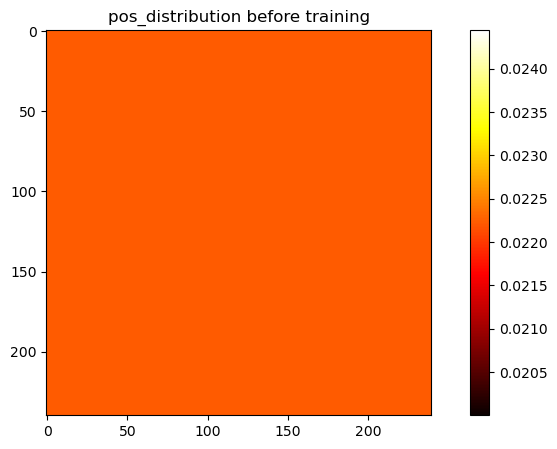

In [ ]:
import matplotlib.pyplot as plt

# Plot pos_distribution before training
plt.figure(figsize=(10, 5))
plt.title('pos_distribution before training')
plt.imshow(pos_distribution[20].detach().cpu().numpy(), cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

In [ ]:
for k in range(n_iter):
    optimizer.zero_grad()
    total_loss = 0 # Initialize total_loss for each iteration 
    for n in range(n_draw):
        delete_files(file_paths)
        #output, total_loss = model()
        output,loss_draw = model.forward()
    total_loss += loss_draw

    mean_loss = total_loss / n_draw
    #with torch.no_grad():
    mean_loss.backward()
    optimizer.step()
    print(f"Mean loss after iteration {k}: {mean_loss.item()}")
    total_loss = 0

 25%|██▍       | 80/324 [00:03<00:10, 23.49it/s]


KeyboardInterrupt: 

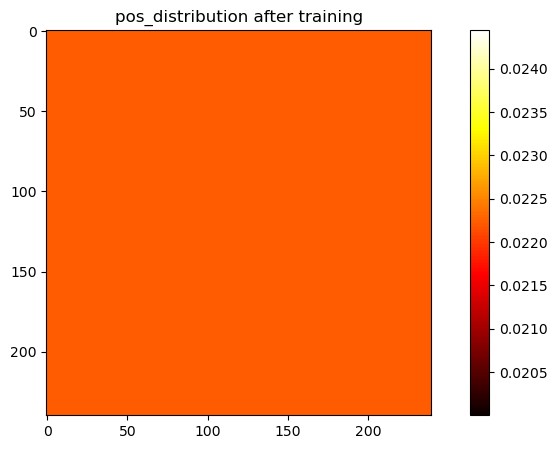

In [ ]:
# Plot pos_distribution after training
plt.figure(figsize=(10, 5))
plt.title('pos_distribution after training')
plt.imshow(model.pos_distribution[20].detach().cpu().numpy(), cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()